In [1]:
!pip install cake-ensemble

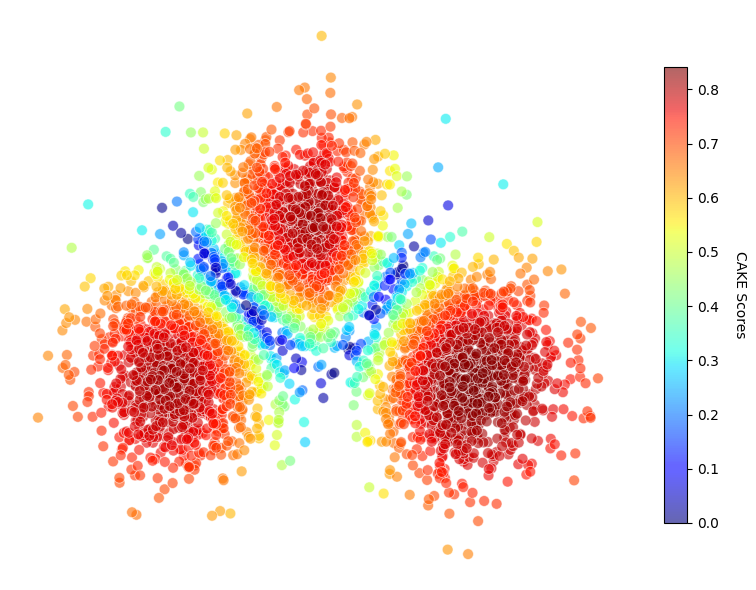

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from cake_ensemble import cake

# Generate synthetic data with intersecting boundaries
X_core, _ = make_blobs(
    n_samples=4000,
    centers=[[0, 0], [5, 5], [12, 0]],
    cluster_std=2,
    random_state=42
)

# Generate a fast KMeans ensemble
labels_list = [
    KMeans(n_clusters=3, random_state=seed, n_init=1).fit_predict(X_core)
    for seed in range(0, 10)
]

# Compute CAKE scores
scores, _, _, summary = cake(
    X_core,
    labels_list,
    method='harmonic_mean'
)

# Visualize the confidence scores
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_core[:, 0], X_core[:, 1],
    c=scores,
    cmap="jet",
    s=60,
    alpha=0.6,
    linewidth=0.6,
    edgecolor='w'
)

cbar = plt.colorbar(scatter, shrink=0.8)
cbar.set_label('CAKE Scores', rotation=270, labelpad=20)

plt.xticks([])
plt.yticks([])
ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()